# Libraries

In [3]:
# import pylab as pl
# import numpy as np
# from astropy.visualization import quantity_support
# from astropy import units as u
# import string
# from astropy import wcs

# pl.rcParams['figure.facecolor']='w'

# from spectral_cube import SpectralCube
# from pvextractor import extract_pv_slice, Path
# import matplotlib.pyplot as plt
# from astropy.wcs import WCS

# import pyspeckit
# import astropy.units as u
# import astropy.wcs as wcs
# import aplpy as aplpy
# from astropy.io import fits
# from astropy.wcs.utils import skycoord_to_pixel
# from astropy.wcs.utils import pixel_to_skycoord
# from astropy.coordinates import SkyCoord

# from matplotlib.patches import Ellipse
# from matplotlib.patches import Circle

# from skimage.morphology import remove_small_objects
# from astropy.stats import mad_std

# import matplotlib as mpl


import numpy as np
import string
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import astropy.units as u
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord
from matplotlib.patches import Ellipse
from astropy.stats import mad_std
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})


# Functions

In [4]:
def plot_contours(data_array, color, sigma_m0, sigma_min, sigma_max, sigma_step):
    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma_m0 * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=[
            ra_offsets.min(), ra_offsets.max(),
            dec_offsets.min(), dec_offsets.max()
        ],
    )


def beam(beam_minor, beam_major, beam_pa, beam_position_x, beam_position_y):
    # Set beam location
    beam_x = ra_offsets.min() + beam_position_x
    beam_y = dec_offsets.min() + beam_position_y

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )

# Read 12CO Data

In [5]:
cube_12CO= SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_12CO.allow_huge_operations = True 
cube_12CO = cube_12CO.to(u.K).with_spectral_unit(u.km/u.s)

In [6]:
sigma_m5_12CO = 0.13

In [7]:
# Emission:
vmin_12CO = -4.6
vmax_12CO = 19.2

# All emission
slab_12CO = cube_12CO.spectral_slab(0*u.km/u.s, 11.6*u.km/u.s)
data_moment0_12CO = slab_12CO.moment(order=0).hdu.data 

# Outflow
slab_12CO_blue = cube_12CO.spectral_slab(0*u.km/u.s, 4.2*u.km/u.s)
data_moment0_12CO_blue = slab_12CO_blue.moment(order=0).hdu.data  

slab_12CO_red = cube_12CO.spectral_slab(7.2*u.km/u.s, 11.6*u.km/u.s)
data_moment0_12CO_red = slab_12CO_red.moment(order=0).hdu.data  


In [8]:
# # Finding RMS
# dv = np.abs(np.diff(slab_12CO.spectral_axis)[0])
# N = slab_12CO.shape[0]
# sigma_12CO = sigma_m5_12CO * np.sqrt(N) * dv
# print(sigma_12CO)

# Set Offset

In [9]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

# Transform it to the same offset frame as your image
marker_offset = marker_coord.transform_to(offset_frame)

# Access robust data
data_robust = cube_12CO.hdu.data

# Convert pixel grid to world coordinates
nx = cube_12CO.shape[1]
ny = cube_12CO.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_12CO.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_12CO.wcs.celestial)

# High, Medium, and Low Velocities

0.030956599638842754 km / s
0.037205202437282314 km / s
0.05159433273140459 km / s
0.13254824073517424 km / s
0.11628772017539715 km / s
0.11628772017540756 km / s


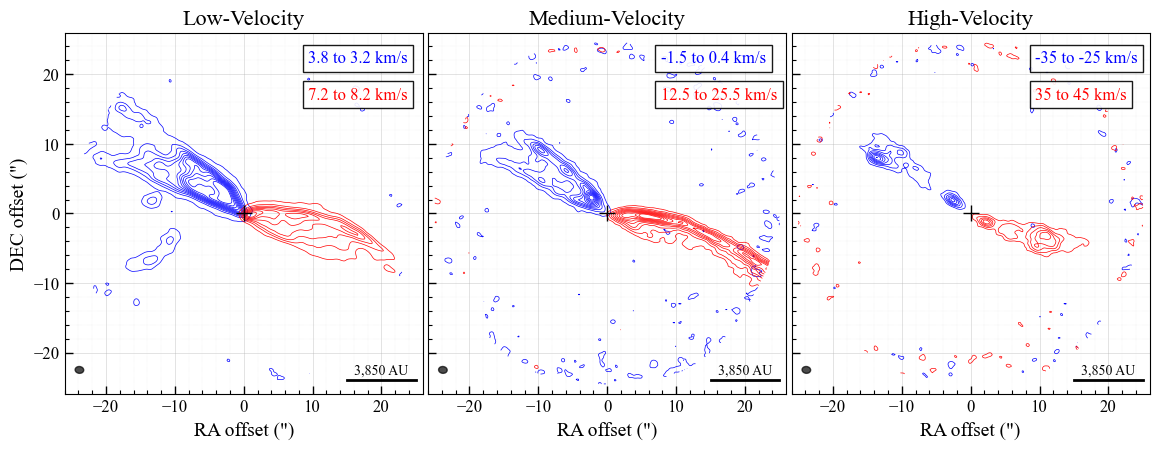

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))

# high_velocity_blue1 = -35
# high_velocity_blue2 = -25
# high_velocity_red1 = 35
# high_velocity_red2 = 45

# medium_velocity_blue1 = -15
# medium_velocity_blue2 = -5
# medium_velocity_red1 = 15
# medium_velocity_red2 = 25

# low_velocity_blue1 = -5
# low_velocity_blue2 = 5
# low_velocity_red1 = 5
# low_velocity_red2 = 15

high_velocity_blue1 = -35 #
high_velocity_blue2 = -25 #
high_velocity_red1 = 35 #
high_velocity_red2 = 45 #

medium_velocity_blue1 = -1.5 #
medium_velocity_blue2 = 0.4 #
medium_velocity_red1 = 12.5
medium_velocity_red2 = 25.5

low_velocity_blue1 = 3.8 #
low_velocity_blue2 = 3.2 #
low_velocity_red1 = 7.2
low_velocity_red2 = 8.2

for idx, i in enumerate(range(1,4)):  
    ax = axes[idx]
    
    if i==3:

        # High Velocities
        slab_high_blue_12CO = cube_12CO.spectral_slab(high_velocity_blue1*u.km/u.s, high_velocity_blue2*u.km/u.s)
        moment0_high_blue_12CO = slab_high_blue_12CO.moment(order=0).hdu.data

        slab_high_red_12CO = cube_12CO.spectral_slab(high_velocity_red1*u.km/u.s, high_velocity_red2*u.km/u.s)
        moment0_high_red_12CO = slab_high_red_12CO.moment(order=0).hdu.data

        # # Plot the moment 0 map
        # im = ax.imshow(moment0_high_blue_12CO, cmap='binary', origin='lower', vmin=0, extent=[
        # ra_offsets.min(), ra_offsets.max(),
        # dec_offsets.min(), dec_offsets.max()])

        # # Plot the moment 0 map
        # im = ax.imshow(moment0_high_red_12CO, cmap='binary', origin='lower', vmin=0, extent=[
        # ra_offsets.min(), ra_offsets.max(),
        # dec_offsets.min(), dec_offsets.max()])

        # Finding RMS
        dv = np.abs(np.diff(slab_high_blue_12CO.spectral_axis)[0])
        N = slab_high_blue_12CO.shape[0]
        sigma_12CO_high_blue = sigma_m5_12CO * np.sqrt(N) * dv
        print(sigma_12CO_high_blue)

        # Finding RMS
        dv = np.abs(np.diff(slab_high_red_12CO.spectral_axis)[0])
        N = slab_high_red_12CO.shape[0]
        sigma_12CO_high_red = sigma_m5_12CO * np.sqrt(N) * dv
        print(sigma_12CO_high_red)

        plot_contours(moment0_high_blue_12CO, 'blue', sigma_12CO_high_blue, sigma_min=7, sigma_max=50, sigma_step=7)
        plot_contours(moment0_high_red_12CO, 'red', sigma_12CO_high_red, sigma_min=7, sigma_max=40, sigma_step=7)

        # Add velocity label in the top left of the subplot
        ax.text(0.68, 0.95, f"{high_velocity_blue1} to {high_velocity_blue2} km/s", transform=ax.transAxes, fontsize=12, color = 'blue',
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
        
        # Add velocity label in the top left of the subplot
        ax.text(0.68, 0.85, f"{high_velocity_red1} to {high_velocity_red2} km/s", transform=ax.transAxes, fontsize=12, color = 'red',
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

        ax.set_xlabel('RA offset (")')
        ax.set_ylabel('DEC offset (")')

        ax.set_title("High-Velocity")

    if i==2:

        # Medium Velocities
        slab_medium_blue_12CO = cube_12CO.spectral_slab(medium_velocity_blue1*u.km/u.s,medium_velocity_blue2*u.km/u.s)
        moment0_medium_blue_12CO = slab_medium_blue_12CO.moment(order=0).hdu.data

        slab_medium_red_12CO = cube_12CO.spectral_slab(medium_velocity_red1*u.km/u.s, medium_velocity_red2*u.km/u.s)
        moment0_medium_red_12CO = slab_medium_red_12CO.moment(order=0).hdu.data

        # # Plot the moment 0 map
        # im = ax.imshow(moment0_medium_blue_12CO, cmap='binary', origin='lower', vmin=0, extent=[
        # ra_offsets.min(), ra_offsets.max(),
        # dec_offsets.min(), dec_offsets.max()])

        # # Plot the moment 0 map
        # im = ax.imshow(moment0_medium_red_12CO, cmap='binary', origin='lower', vmin=0, extent=[
        # ra_offsets.min(), ra_offsets.max(),
        # dec_offsets.min(), dec_offsets.max()])

        # Finding RMS
        dv = np.abs(np.diff(slab_medium_blue_12CO.spectral_axis)[0])
        N = slab_medium_blue_12CO.shape[0]
        sigma_12CO_medium_blue = sigma_m5_12CO * np.sqrt(N) * dv
        print(sigma_12CO_medium_blue)

        # Finding RMS
        dv = np.abs(np.diff(slab_medium_red_12CO.spectral_axis)[0])
        N = slab_medium_red_12CO.shape[0]
        sigma_12CO_medium_red = sigma_m5_12CO * np.sqrt(N) * dv
        print(sigma_12CO_medium_red)

        plot_contours(moment0_medium_blue_12CO, 'blue', sigma_12CO_medium_blue, sigma_min=5, sigma_max=150, sigma_step=15)
        plot_contours(moment0_medium_red_12CO, 'red', sigma_12CO_medium_red, sigma_min=10, sigma_max=100, sigma_step=10)

        # Add velocity label in the top left of the subplot
        ax.text(0.65, 0.95, f"{medium_velocity_blue1} to {medium_velocity_blue2} km/s", transform=ax.transAxes, fontsize=12, color = 'blue',
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
        
        # Add velocity label in the top left of the subplot
        ax.text(0.65, 0.85, f"{medium_velocity_red1} to {medium_velocity_red2} km/s", transform=ax.transAxes, fontsize=12, color = 'red',
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

        ax.set_xlabel('RA offset (")')
        ax.set_ylabel('DEC offset (")')

        ax.set_title("Medium-Velocity")

    if i==1:
        # Low Velocities
        slab_low_blue_12CO = cube_12CO.spectral_slab(low_velocity_blue1*u.km/u.s, low_velocity_blue2*u.km/u.s)
        moment0_low_blue_12CO = slab_low_blue_12CO.moment(order=0).hdu.data

        slab_low_red_12CO = cube_12CO.spectral_slab(low_velocity_red1*u.km/u.s, low_velocity_red2*u.km/u.s)
        moment0_low_red_12CO = slab_low_red_12CO.moment(order=0).hdu.data

        # # Plot the moment 0 map
        # im = ax.imshow(moment0_low_blue_12CO, cmap='binary', origin='lower', vmin=0, extent=[
        # ra_offsets.min(), ra_offsets.max(),
        # dec_offsets.min(), dec_offsets.max()])

        # # Plot the moment 0 map
        # im = ax.imshow(moment0_low_red_12CO.data, cmap='binary', origin='lower', vmin=0, extent=[
        # ra_offsets.min(), ra_offsets.max(),
        # dec_offsets.min(), dec_offsets.max()])

        # Finding RMS
        dv = np.abs(np.diff(slab_low_blue_12CO.spectral_axis)[0])
        N = slab_low_blue_12CO.shape[0]
        sigma_12CO_low_blue = sigma_m5_12CO * np.sqrt(N) * dv
        print(sigma_12CO_low_blue)

        # Finding RMS
        dv = np.abs(np.diff(slab_low_red_12CO.spectral_axis)[0])
        N = slab_low_red_12CO.shape[0]
        sigma_12CO_low_red = sigma_m5_12CO * np.sqrt(N) * dv
        print(sigma_12CO_low_red)

        plot_contours(moment0_low_blue_12CO, 'blue', sigma_12CO_low_blue, sigma_min=10, sigma_max=330, sigma_step=30)
        plot_contours(moment0_low_red_12CO, 'red', sigma_12CO_low_red, sigma_min=230, sigma_max=550, sigma_step=50)

        # Add velocity label in the top left of the subplot
        ax.text(0.68, 0.95, f"{low_velocity_blue1} to {low_velocity_blue2} km/s", transform=ax.transAxes, fontsize=12, color = 'blue',
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
        
        # Add velocity label in the top left of the subplot
        ax.text(0.68, 0.85, f"{low_velocity_red1} to {low_velocity_red2} km/s", transform=ax.transAxes, fontsize=12, color = 'red',
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

        ax.set_xlabel('RA offset (")')
        ax.set_ylabel('DEC offset (")')

        ax.set_title("Low-Velocity")
    
    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='black', markersize=12)

    # Add beam
    beam_12CO = beam(1.25, 0.98, 84.20, 15, 15)
    ax.add_patch(beam_12CO)

    ax.set_xlim(-26, 26) 
    ax.set_ylim(-26, 26)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 26, 10))
    ax.set_yticks(np.arange(-20, 26, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-20, 26, 2), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

    # Set starting point for the scale bar (in arcseconds)
    x_start = ax.get_xlim()[0] + 41    # 5" from left
    y_start = ax.get_ylim()[0] + 2    # 5" from bottom

    # Length of the bar in arcseconds
    scale_bar_length = 10  # arcseconds

    # Plot the scale bar
    ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

    # Label it
    ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

    # Only the **first (leftmost)** subplot shows y-axis labels and ticks
    if idx > 0:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='K.km/s')

plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'monospace', etc.
plt.rcParams['font.serif'] = ['Times New Roman']  # Or any font you have installed

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

plt.savefig("HOPS164_12CO_HML_velocity_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_12CO_HML_velocity_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# All Channel Maps

NameError: name 'CO_sigma' is not defined

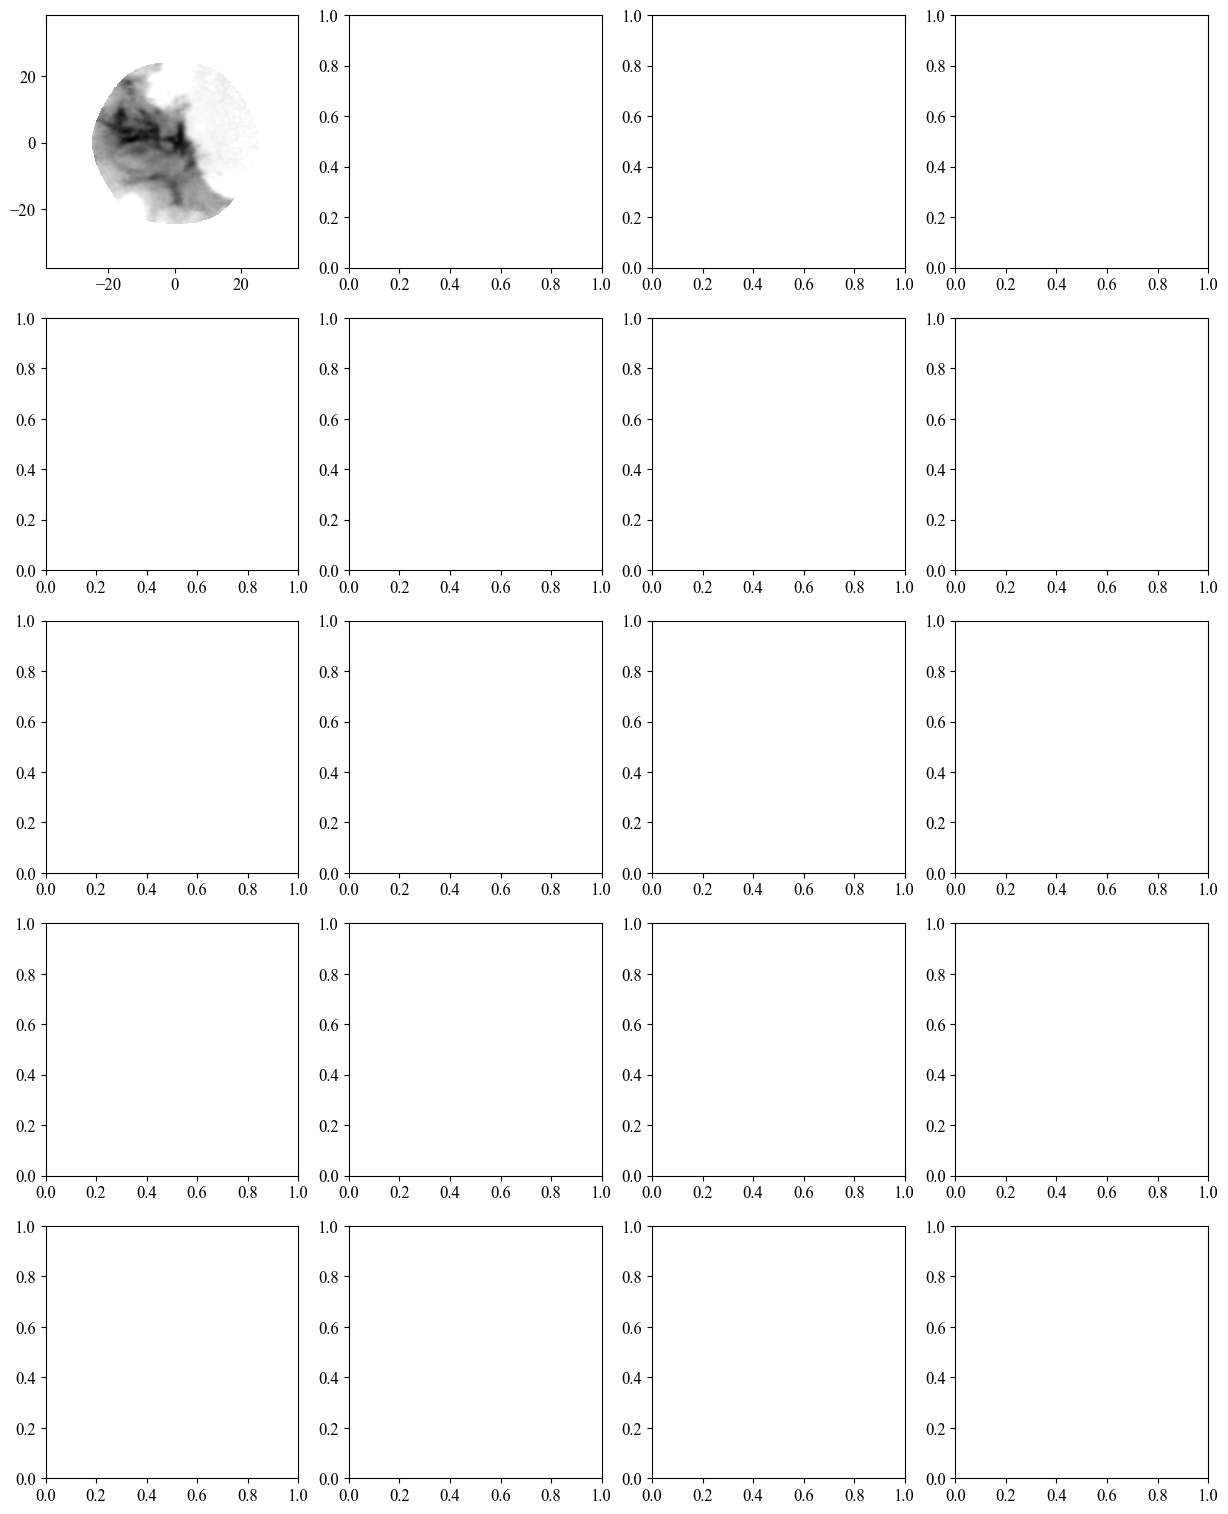

In [10]:
fig, axes = plt.subplots(5, 4, figsize=(15, 19))

for idx, i in enumerate(range(520, 540)):  
    row = idx // 4  # Calculate the row index (0 to 4)
    col = idx % 4   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    # Plot the data slice
    im = ax.imshow(cube_12CO[i, :, :].value, cmap='binary', origin='lower', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

    # Plot contours with proper data handling
    contour_data = np.nan_to_num(cube_12CO[i, :, :].value)  # Replace NaNs with zeros
    plot_contours(contour_data, 'black', levels=[3*CO_sigma, 5*CO_sigma, 40*CO_sigma, 75*CO_sigma, 110*CO_sigma, 145*CO_sigma])
    # plot_contours(Mom0_red.value, 'red', levels=[30*CO_sigma, 120*CO_sigma, 180*CO_sigma, 240*CO_sigma, 300*CO_sigma, 360*CO_sigma])
    # plot_contours(Mom0_blue.value, 'blue', levels=[30*CO_sigma, 120*CO_sigma, 180*CO_sigma, 240*CO_sigma, 300*CO_sigma, 360*CO_sigma])

    # Get velocity for the current slice
    velocity = cube_12CO.spectral_axis[i].to(u.km / u.s).value

    # Add velocity label in the top left of the subplot
    ax.text(0.05, 0.95, f"{velocity :.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    # Add beam
    beam_12CO = beam(1.25, 0.98, 84.20, 15)
    ax.add_patch(beam_12CO)

    ax.set_xlim(-26, 26) 
    ax.set_ylim(-26, 26)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 26, 10))
    ax.set_yticks(np.arange(-20, 26, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-26, 26, 2), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 4:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (arcsec)')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (arcsec)')

    # Hide tick labels for non-edge plots
    if row < 4:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Jy/beam.km/s')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_N2Dp_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()